# Uczenie maszynowe. Lista 3
### Wprowadzenie do klasyfikacji przez regresję

**Rys teoretyczny.** _Klasyfikacja_ to zadanie polegające na przypisaniu obiektów określonych na pewnej dziedzinie do określonych kategorii.
W kontekście uczenia maszynowego rozumiemy przez to, że proces ten przebiega w oparciu o wzorce _nauczone_ z danych uczących.
Aby matematycznie sformalizować to zadanie zakładamy, że dziedzina stanowi pewną przestrzeń wektorową, a więc obiekty - dane - można reprezentować za pomocą $d$-wymiarowego wektora ($x \in \mathbb{R}^d$).
Bez straty ogólności przyjmijmy również, że każdy obiekt może należeć tylko do jednej z $k$ kategorii jednocześnie ($y \in \{0, \cdots, k-1\}$).
Przy tych założeniach "przypisanie obiektów do kategorii" można wyrazić jako znalezienie takiej funkcji $f(x)$, która dla wszystkich danych wejściowych ($X$) "najlepiej" przewiduje ich kategorie ($\hat{Y}$).

W istocie, _znalezienie pewnej funkcji_ stanowi podstawowy problem dla bodaj całej dziedziny uczenia maszynowego;
w związku z tym odejdźmy na moment od klasyfikacji i zastanówmy się nad tym ogólnym problemem.

**Regresja.** W zadaniach klasy _uczenia nadzorowanego_ zakładamy, że dysponujemy tzw. _zbiorem uczącym_ $(x,y)$ zawierającym przykłady obiektów $x$ oraz znanych wartości odpowiadających im zmiennych zależnych $y$ (tj. _etykiet_).
W trakcie procesu uczenia przyjmujemy pewną funkcję $f$ (często zapisywaną jako $f(x,\theta)$) a następnie znajdujemy takie wartości parametrów tej funkcji ($\theta$), że zwracane przez nią wartości $\hat{y}=f(x,\theta)$ będą jak najlepiej odpowiadały etykietom $y$.
Sformułowanie "jak najlepiej" sformalizujemy przy pomocy odrębnej funkcji, zwanej _funkcją kosztu_ ($L(y,\hat{y})$, nieraz $\mathcal{L(y,\hat{y})}$).
$L(y,\hat{y})=0$ oznacza idealne dopasowanie pomiędzy predykcjami modelu $\hat{y}$ a etykietami $y$, a im większa wartość $L$ tym dopasowanie gorsze.
Znalezienie wartości wektora $\theta$ odbywa się zwykle w drodze _optymalizacji_ i zależy ściśle od doboru funkcji $f$ - na tym etapie nie będziemy podejmować tego tematu.

**Na przykład,** załóżmy zbiór o jednowymiarowej dziedzinie ($x \in \mathbb{R}^1$):
$$X=\begin{bmatrix}1.0\\2.0\\3.0\end{bmatrix}; Y=\begin{bmatrix}0\\3\\8\end{bmatrix}$$
Moglibyśmy w tym przypadku odgadnąć, że dobrą funkcją opisującą tę zależność będzie funkcja kwadratowa.
Dla spójności notacji, zapiszmy ją w następujący sposób:
$$f(x,\theta) = \theta_2 \cdot x^2 + \theta_1 \cdot x + \theta_0$$
Teraz naszym zadaniem będzie znaleźć takie wartości wektora parametrów $\theta$, żeby wynik funkcji $\hat{y}=f(x,\theta_{best})$ był jak najbliższy prawdzie ($y$).
Przyjąwszy funkcję kosztu np. $L(y,\hat{y})=\lvert y-\hat{y} \rvert$ można sprawdzić, że jej wartość jest najniższa dla $\theta_{best}=\{1.0, 0.0, -1.0\}$.

$f$ może przyjmować dowolną strukturę, co pociąga za sobą inną interpretację wektora $\theta$.
W trakcie tego i innych kursów poznasz różne algorytmy i modele, które wszystkie można interpretować w powyższy sposób.
Na przykład:
- gdy za $f$ przyjmiemy maszynę wektorów nośnych (SVM), $\theta$ stanowi zbiór $k$ $d$-wymiarowych wektorów oraz bias
- gdy $f$ jest drzewem decyzyjnym, $\theta$ opisuje strukturę drzewa (indeksy wymiarów i progi podziałów dla każdego węzła)
- dla $f$ zdefiniowanej jako sieć neuronowa, $\theta$ jest zestawem wag neuronów tej sieci
- itd.

**Notacja:**
- $x$ ($x_i$) - $d$-wymiarowy wektor opisujący ($i$-tą) próbkę
- $X$ - macierz $n \times d$ zawierająca $n$ próbek
- $y$ ($y_i$) - skalar opisujący _prawdziwą_ wartość zmiennej zależnej dla ($i$-tej) próbki
- $Y$ - wektor $n$-wymiarowy zawierający wartości zmiennej zależnej dla $n$ próbek
- $\hat{y}$ ($\hat{y_i}$) - _przewidziana_ wartość zmiennej zależnej dla ($i$-tej) próbki
- $\hat{Y}$ - wektor $n$-wymiarowy zawierający przewidziane wartości zmiennej zależnej dla $n$ próbek
- $f$, $f(x)$ - szukana funkcja (model)
- $\theta$ - parametry szukanej funkcji (modelu) -- w rozumieniu $f(x,\theta)$
- $L$, $\mathcal{L}$ - funkcja kosztu (straty)

---

### Tutorial
W tym tutorialu zapoznasz się z podstawami uczenia maszynowego rozumianego jako _znajdowanie funkcji pasującej do danych_.
Samodzielnie poprowadzisz miniaturowe eksperymenty i zaobserwujesz w małej skali istotne zjawiska.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.special

Dla przykładu wyobrazimy sobie pewien (sztuczny) proces, który będziemy próbowali zamodelować.
Wykonamy jego "obserwacje" w pewnych punktach, które będą stanowiły zbiór uczący.

In [2]:
# --- NIE MODYFIKUJ TEJ KOMÓRKI ---
def data_generating_process(x):
    """Symulacja pewnego zjawiska (np. reakcji chemicznej - mierzymy wynikowe stężenie y przy założonej temperaturze x)."""
    return scipy.special.struve(np.pi/1.5, x) / (x+1) + np.sin(9*x) / 40 + np.random.normal(0.0, 0.001, size=len(x))

X0, X1 = 5, 12  # brzegi dziedziny
N = 20          # liczba punktów dziedziny
x = np.linspace(X0, X1, N)
y = data_generating_process(x)
# ---

Ponieważ powstały zbiór danych jest jednowymiarowy, możemy go przedstawić na wykresie.

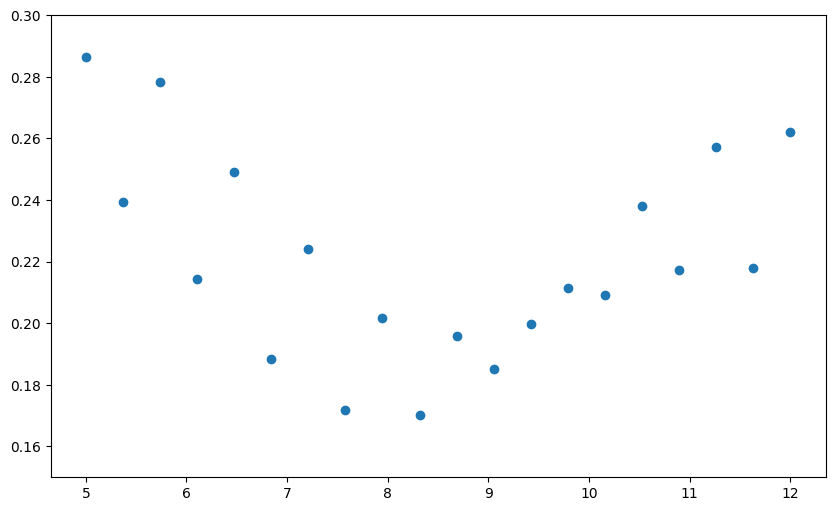

In [3]:
_, fig = plt.subplots(1, 1, figsize=(10,6))
fig.scatter(x,y)
fig.set_ylim([0.15, 0.30]);

Dane jednowymiarowe rzadko spotyka się w praktyce, ale dobrze pozwalają one na zwizualizowanie pewnych zjawisk.
Pozwalają one także na aproksymację za pomocą wielomianów; tj. model przyjmie postać:
$$f(x,\theta) = \theta_{n} \cdot x^n + \theta_{n-1} \cdot x^{n-1} + \cdots + \theta_1 \cdot x + \theta_0$$
Aby z nich skorzystać, skorzystamy z API [`numpy.polynomial`](https://numpy.org/doc/stable/reference/generated/numpy.polynomial.polynomial.Polynomial.html#numpy.polynomial.polynomial.Polynomial).
Zacznijmy od wielomianu stopnia 2.

[ 0.1916836  -0.00719655  0.07930826]


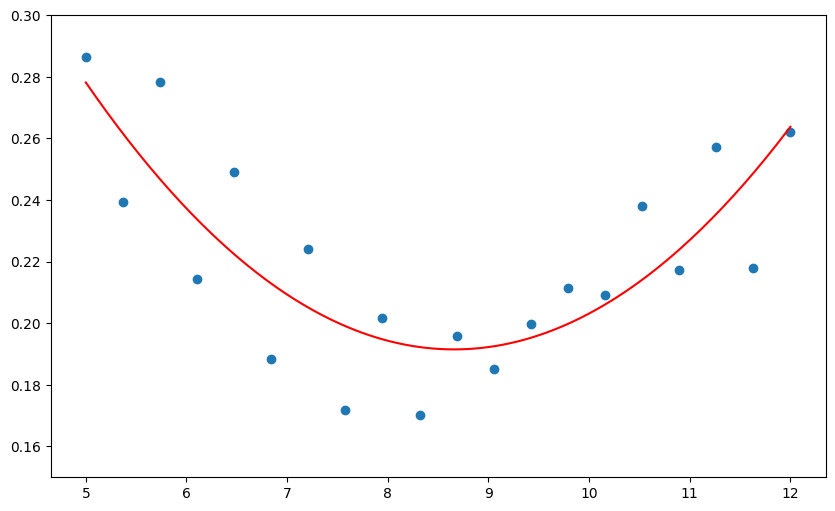

In [4]:
# dopasowanie wielomianu do danych
f = np.polynomial.Polynomial.fit(x, y, deg=2)
# rysowanie wykresu
x_plot, yhat_plot = f.linspace(n=10*N, domain=[X0, X1])
_, fig = plt.subplots(1, 1, figsize=(10,6))
fig.scatter(x, y)
fig.plot(x_plot, yhat_plot, c='r')
fig.set_ylim([0.15, 0.30]);
# sprawdzenie wartości parametrów modelu (theta)
print(f.coef)

Widać "na oko", że dopasowanie nie jest idealne: model myli się dla każdego punktu w zbiorze danych - krzywa niemal nigdy nie przechodzi przez punkty danych.
Możemy skwantyfikować tę obserwację poprzez wprowadzenie funkcji kosztu.
Dla problemów regresyjnych, jak wyżej, często używaną funkcją jest _błąd średniokwadratowy_ (_mean squared error_, MSE):
$$L_{MSE}(Y,\hat{Y}) = \frac{1}{n}\sum_{i}^{n}(y_{i}-\hat{y_i})^2$$

In [5]:
def MSE(target, prediction):
    return np.sum((target-prediction)**2) / target.size

Dla naszego zbioru danych błąd wyniesie:

In [6]:
yhat = f(x)  # ewaluacja modelu dla zadanych próbek
MSE(y, yhat)

np.float64(0.0003589745903790051)

Sprawdź, jak zmieni się zachowanie modelu, jeśli zwiększysz stopień wielomianu.
Inkrementuj go stopniowo, aż dalsza poprawa przestanie być możliwa.
Obserwuj zarówno jakościowe efekty (kształt krzywej) jak i błąd modelu.
_Co dzieje się z wartościami samych parametrów modelu?_

[ 1.78018535e-01  3.29434147e-01  2.01291190e+00 -3.34563428e+01
 -8.48142609e+01  1.00514760e+03  1.40252916e+03 -1.31175363e+04
 -1.10313138e+04  8.86722327e+04  4.65612503e+04 -3.37811160e+05
 -1.10901862e+05  7.48629331e+05  1.48528420e+05 -9.51674222e+05
 -1.03846378e+05  6.40262229e+05  2.93702522e+04 -1.75932907e+05]


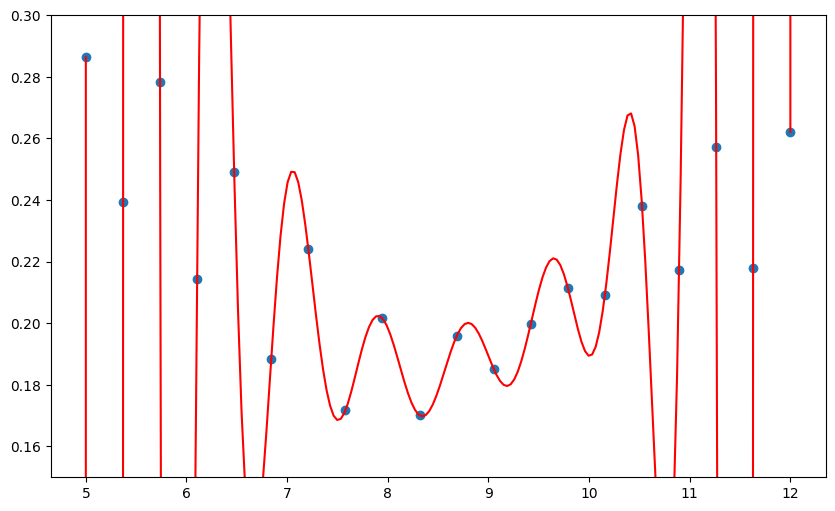

In [49]:

# dopasowanie wielomianu do danych
f = np.polynomial.Polynomial.fit(x, y, deg=19)
# rysowanie wykresu
x_plot, yhat_plot = f.linspace(n=10*N, domain=[X0, X1])
_, fig = plt.subplots(1, 1, figsize=(10,6))
fig.scatter(x, y)
fig.plot(x_plot, yhat_plot, c='r')
fig.set_ylim([0.15, 0.30]);
# sprawdzenie wartości parametrów modelu (theta)
print(f.coef)











In [50]:
yhat = f(x)  # ewaluacja modelu dla zadanych próbek
MSE(y, yhat)

np.float64(9.24662266756899e-21)

Jak widać, możliwe jest idealne (z dokładnością do reprezentacji zmiennoprzecinkowej) dopasowanie modelu do danych.
Pytanie, co ze _zdolnością predykcyjną_ tak dopasowanego modelu? Czy można ufać, że dla nowych danych będzie dobrze się sprawdzał?

Aby to sprawdzić, wykonamy eksperyment ("reakcję chemiczną") ponownie, dla nieco innych wartości "temperatury".
Następnie Ty sprawdzisz, jak predykcje modelu mają się do nowych danych.

In [51]:
# powtórny "eksperyment"
unseen_x = np.linspace(X0 + 0.185, X1 - 0.185, num=10)  # nowa dziedzina
unseen_y = data_generating_process(unseen_x)  # nowe obserwacje

MSE: 380.1970401245568



(0.15, 0.3)

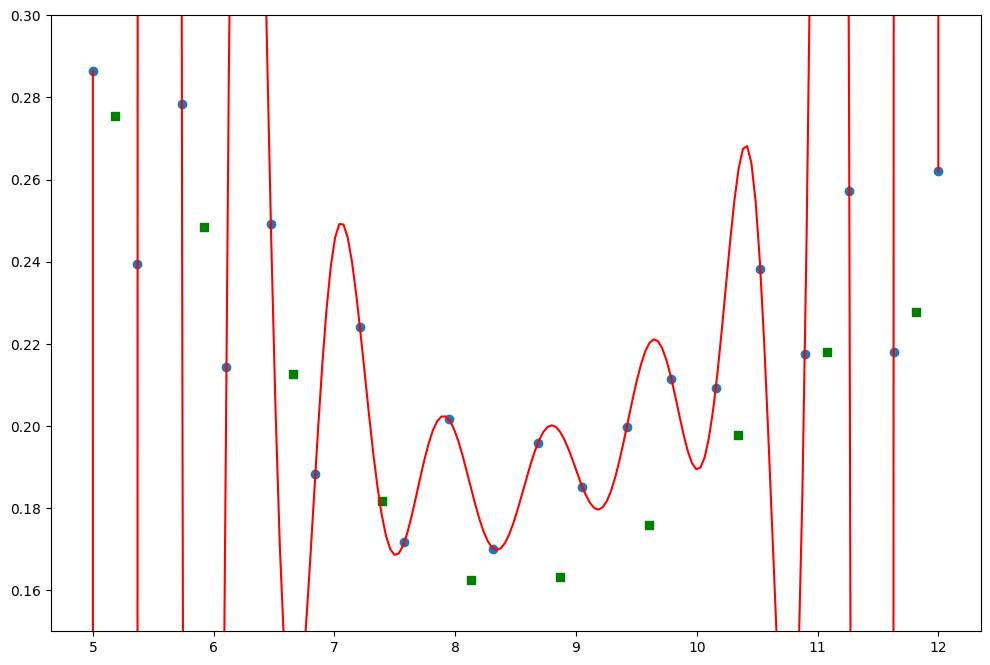

In [52]:
# TODO
unseen_yhat = f(unseen_x)
mse = MSE(unseen_y, unseen_yhat)
print(f'MSE: {mse}')
print()


# rysowanie wykresu
_, fig = plt.subplots(1, 1, figsize=(12,8))
fig.scatter(x, y)
fig.scatter(unseen_x, unseen_y, c='g', marker='s')
fig.plot(x_plot, yhat_plot, c='r')

fig.set_ylim([0.15, 0.30])

Choć powyższy przykład jest nieco zabawkowy, zjawiska, które ilustruje, są uniwersalne i mają miejsce _zawsze_ podczas pracy z modelami, w mniejszym lub większym stopniu.
Przedstawienie ich na tak prostym problemie i modelu ma natomiast tę zaletę, że zjawiska te są bardzo wyraźnie widoczne "gołym okiem", co z reguły nie ma miejsca gdy pracujemy na prawdziwych, złożonych danych i skomplikowanych modelach ML.

Uniwersalne są również wnioski, które z tego tutorialu należy wyciągnąć;
powinny one odpowiadać na conajmniej dwa najważniejsze pytania:
- Jak należy postępować z danymi, aby uniknąć (a przynajmniej w porę dostrzec) problem nadmiernego dopasowania (_overfitting_)?
- Jak należy dobierać hiperparametry modelu, aby zminimalizować ryzyko wystąpienia tego zjawiska?  
Jaki efekt uboczny może w takim podejściu wystąpić?